# Análisis de Eficiencia Hospitalaria en Chile — REM 20 MINSAL
### Análisis de Datos e Inferencia Estadística
**Universidad del Desarrollo – Facultad de Ingeniería**

| Campo | Detalle |
|-------|---------|
| **Dataset** | Indicadores REM 20 — Actividad hospitalaria (MINSAL, datos.gob.cl) |
| **Período** | 2014 – 2025 |
| **Integrantes** | Valentin Castro · Pablo Lineros |
| **Profesor| Cristian Orlando |
| **Fecha** | 8 de abril de 2025 |



## 0. Glosario de Variables

Antes de comenzar el análisis definimos cada variable del dataset para asegurar
una interpretación correcta y reproducible.


In [1]:
GLOSARIO = {
    "PERIODO":                   "Año del registro (2014–2025)",
    "TIPO_PERTENENCIA":          "Tipo de establecimiento (1=público, 2=privado, etc.)",
    "COD_SSS / GLOSA_SSS":       "Código y nombre del Servicio de Salud al que pertenece",
    "CODIGO_ESTABLECIMIENTO":    "Código único del hospital",
    "ESTABLECIMIENTO":           "Nombre del hospital",
    "COD_AREA_FUNCIONAL":        "Código del área clínica dentro del hospital",
    "AREA_FUNCIONAL":            "Nombre del área clínica (ej: UCI Adultos, Obstetricia)",
    "MES":                       "Mes del registro (1–12)",
    "DIAS_CAMAS_OCUPADAS":       "Total de días que las camas estuvieron ocupadas en el mes",
    "DIAS_CAMAS_DISPONIBLES":    "Total de días que las camas estuvieron disponibles",
    "DIAS_ESTADA":               "Suma de días de hospitalización de todos los egresos",
    "NUMERO_EGRESOS":            "Cantidad de pacientes egresados (altas + fallecidos + traslados)",
    "EGRESOS_FALLECIDOS":        "Egresos por fallecimiento",
    "TRASLADOS":                 "Pacientes trasladados a otro establecimiento",
    "INDICE_OCUPACIONAL":        "% de camas ocupadas respecto a camas disponibles",
    "PROMEDIO_CAMAS_DISPONIBLE": "Promedio de camas disponibles en el mes",
    "PROMEDIO_DIAS_ESTADA":      "Promedio de días que un paciente permaneció hospitalizado",
    "LETALIDAD":                 "% de egresos que corresponden a fallecidos",
    "INDICE_ROTACION":           "Número de egresos por cama disponible",
}


print("GLOSARIO DE VARIABLES REM20")
for var, desc in GLOSARIO.items():
    print(f"  {var:<30} → {desc}")


GLOSARIO DE VARIABLES REM20
  PERIODO                        → Año del registro (2014–2025)
  TIPO_PERTENENCIA               → Tipo de establecimiento (1=público, 2=privado, etc.)
  COD_SSS / GLOSA_SSS            → Código y nombre del Servicio de Salud al que pertenece
  CODIGO_ESTABLECIMIENTO         → Código único del hospital
  ESTABLECIMIENTO                → Nombre del hospital
  COD_AREA_FUNCIONAL             → Código del área clínica dentro del hospital
  AREA_FUNCIONAL                 → Nombre del área clínica (ej: UCI Adultos, Obstetricia)
  MES                            → Mes del registro (1–12)
  DIAS_CAMAS_OCUPADAS            → Total de días que las camas estuvieron ocupadas en el mes
  DIAS_CAMAS_DISPONIBLES         → Total de días que las camas estuvieron disponibles
  DIAS_ESTADA                    → Suma de días de hospitalización de todos los egresos
  NUMERO_EGRESOS                 → Cantidad de pacientes egresados (altas + fallecidos + traslados)
  EGRESOS_FALLECIDO


## 1. Importación de Librerías y Configuración


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats
import warnings

warnings.filterwarnings("ignore")


plt.rcParams.update({
    "figure.facecolor":  "white",
    "axes.facecolor":    "white",
    "axes.grid":         True,
    "grid.alpha":        0.4,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "font.size":         11,
})

print("Librerías cargadas correctamente.")


Librerías cargadas correctamente.



## 2. Carga y Limpieza de Datos

### 2.1 Carga del archivo

El CSV usa separador `;` y codificación UTF-8. Se verificó que la lectura con
`encoding="utf-8"` preserva correctamente los caracteres especiales del español.


In [4]:
df_raw = pd.read_csv("indicadores_rem20_20260225.csv", sep=";", encoding="utf-8")

print(f"  Filas cargadas    : {len(df_raw):,}")
print(f"  Columnas          : {df_raw.shape[1]}")
print(f"  Hospitales únicos : {df_raw['ESTABLECIMIENTO'].nunique()}")
print(f"  Período           : {df_raw['PERIODO'].min()} – {df_raw['PERIODO'].max()}")
print()
print(df_raw.dtypes)


  Filas cargadas    : 159,788
  Columnas          : 20
  Hospitales únicos : 313
  Período           : 2014 – 2025

PERIODO                        int64
TIPO_PERTENENCIA               int64
COD_SSS                        int64
GLOSA_SSS                        str
CODIGO_ESTABLECIMIENTO         int64
ESTABLECIMIENTO                  str
COD_AREA_FUNCIONAL             int64
AREA_FUNCIONAL                   str
MES                            int64
DIAS_CAMAS_OCUPADAS            int64
DIAS_CAMAS_DISPONIBLES         int64
DIAS_ESTADA                    int64
NUMERO_EGRESOS                 int64
EGRESOS_FALLECIDOS             int64
TRASLADOS                      int64
INDICE_OCUPACIONAL           float64
PROMEDIO_CAMAS_DISPONIBLE    float64
PROMEDIO_DIAS_ESTADA         float64
LETALIDAD                    float64
INDICE_ROTACION              float64
dtype: object


### 2.2 Limpieza de datos

Antes de cualquier analisis conviene revisar que tan integros estan los datos. Se aplican tres filtros sobre el dataset original, cada uno con una justificacion clinica o tecnica:

1. **`NUMERO_EGRESOS > 0`** — Un servicio sin egresos en el mes corresponde a un periodo de cierre o baja actividad; incluirlo inflarıa artificialmente el denominador de los indicadores.

2. **`PROMEDIO_DIAS_ESTADA > 0`** — Una estancia de 0 dias es incoherente: si hay egreso, el paciente debe haber permanecido al menos un dia.

3. **`INDICE_OCUPACIONAL <= 100`** — Un indice superior al 100% viola una restriccion fisica. Se detectaron registros con valores de hasta 2700%, atribuibles a errores de digitacion en MINSAL.


In [5]:
antes = len(df_raw)

df = df_raw[
    (df_raw["NUMERO_EGRESOS"]       > 0  ) &
    (df_raw["PROMEDIO_DIAS_ESTADA"] > 0  ) &
    (df_raw["INDICE_OCUPACIONAL"]   <= 100)
].copy()

eliminados = antes - len(df)
print(f"  Registros originales : {antes:,}")
print(f"  Registros eliminados : {eliminados:,}  ({eliminados/antes*100:.1f}%)")
print(f"  Registros válidos    : {len(df):,}")
print()

# Se verifican los nulos en las columnas que ocuparemos para nuestro análisis.
nulos = df[["PROMEDIO_DIAS_ESTADA", "INDICE_OCUPACIONAL",
            "NUMERO_EGRESOS", "AREA_FUNCIONAL"]].isnull().sum()
print("Valores nulos en columnas clave:")
print(nulos)



print("\nDetección de outliers por método IQR (Q1 - 1.5·IQR, Q3 + 1.5·IQR):")
for var in ["PROMEDIO_DIAS_ESTADA", "INDICE_OCUPACIONAL", "INDICE_ROTACION"]:
    Q1 = df[var].quantile(0.25)
    Q3 = df[var].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df[var] < lower) | (df[var] > upper)).sum()
    pct   = n_out / len(df) * 100
    print(f"  {var:<30} limites=[{lower:6.2f}, {upper:7.2f}]  outliers={n_out:,} ({pct:.1f}%)")

print("\nCriterio adoptado: los outliers se CONSERVAN porque reflejan")
print("variabilidad clinica real (ej: estadias largas en casos complejos).")
print("Solo se descartaron registros con errores manifiestos (ocupacion > 100%).")

  Registros originales : 159,788
  Registros eliminados : 13,007  (8.1%)
  Registros válidos    : 146,781

Valores nulos en columnas clave:
PROMEDIO_DIAS_ESTADA    0
INDICE_OCUPACIONAL      0
NUMERO_EGRESOS          0
AREA_FUNCIONAL          0
dtype: int64

Detección de outliers por método IQR (Q1 - 1.5·IQR, Q3 + 1.5·IQR):
  PROMEDIO_DIAS_ESTADA           limites=[-12.38,   29.62]  outliers=17,379 (11.8%)
  INDICE_OCUPACIONAL             limites=[-12.74,  150.38]  outliers=0 (0.0%)
  INDICE_ROTACION                limites=[ -3.43,    8.68]  outliers=4,358 (3.0%)

Criterio adoptado: los outliers se CONSERVAN porque reflejan
variabilidad clinica real (ej: estadias largas en casos complejos).
Solo se descartaron registros con errores manifiestos (ocupacion > 100%).


### 2.3 Creación de subconjunto: hospitalización aguda

Para las preguntas 1, 2, 3 y 4 se excluyen áreas de larga estadía (psiquiatría, sociosanitaria)
porque distorsionan las comparaciones de eficiencia en hospitalización de corta/media duración.
La pregunta 5 (saturación) usa el dataset completo `df`, ya que la saturación es relevante
en todas las áreas incluyendo las de larga estadía.

In [6]:
EXCLUIR_AREAS = ["Psiquiatría", "Sociosanitaria"]
mask_excluir  = df["AREA_FUNCIONAL"].str.contains("|".join(EXCLUIR_AREAS), na=False)

df_aguda = df[~mask_excluir].copy()

print(f"  Registros total           : {len(df):,}")
print(f"  Registros hospitaliz. aguda: {len(df_aguda):,}")
print(f"  (Áreas excluidas: {df[mask_excluir]['AREA_FUNCIONAL'].nunique()} tipos de servicio psiquiátrico/sociosanitario)")


  Registros total           : 146,781
  Registros hospitaliz. aguda: 136,196
  (Áreas excluidas: 14 tipos de servicio psiquiátrico/sociosanitario)


### 2.4 Transformaciones

La variable `PROMEDIO_DIAS_ESTADA` presenta sesgo positivo marcado (muchos valores bajos y algunos valores extremadamente altos). Se explora una transformacion logaritmica `log(1+x)` para normalizar la distribucion antes de aplicar metodos que asumen normalidad.


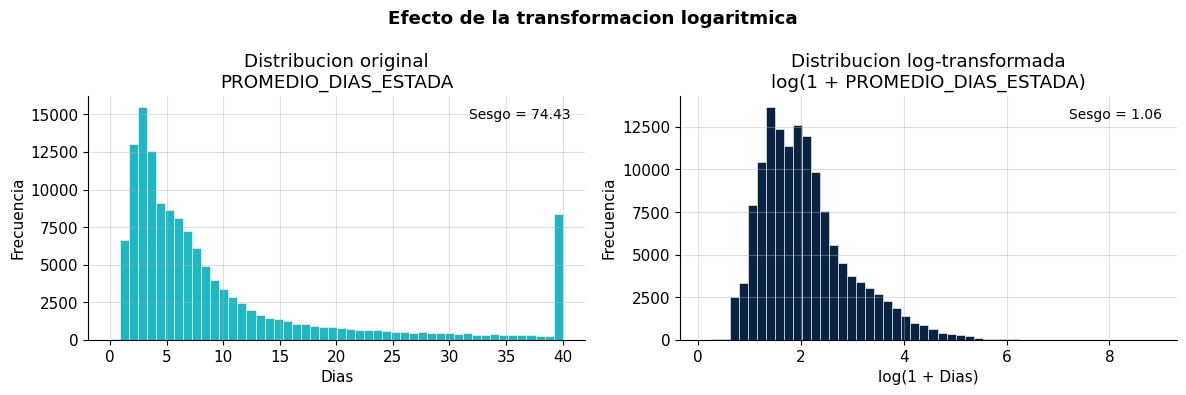

Sesgo original : 74.425
Sesgo log(1+x) : 1.062
La transformacion logaritmica reduce sustancialmente el sesgo positivo.


In [ ]:

df_aguda = df_aguda.copy()
df_aguda["log_estancia"] = np.log1p(df_aguda["PROMEDIO_DIAS_ESTADA"])

fig, (ax_orig, ax_log) = plt.subplots(1, 2, figsize=(12, 4))

ax_orig.hist(df_aguda["PROMEDIO_DIAS_ESTADA"].clip(upper=40),
             bins=50, color="#1EB8C5", edgecolor="white", linewidth=0.4)
ax_orig.set_title("Distribucion original\nPROMEDIO_DIAS_ESTADA")
ax_orig.set_xlabel("Dias")
ax_orig.set_ylabel("Frecuencia")
sk_orig = df_aguda["PROMEDIO_DIAS_ESTADA"].skew()
ax_orig.text(0.97, 0.95, f"Sesgo = {sk_orig:.2f}", ha="right", va="top",
             transform=ax_orig.transAxes, fontsize=10)

ax_log.hist(df_aguda["log_estancia"],
            bins=50, color="#0A2342", edgecolor="white", linewidth=0.4)
ax_log.set_title("Distribucion log-transformada\nlog(1 + PROMEDIO_DIAS_ESTADA)")
ax_log.set_xlabel("log(1 + Dias)")
ax_log.set_ylabel("Frecuencia")
sk_log = df_aguda["log_estancia"].skew()
ax_log.text(0.97, 0.95, f"Sesgo = {sk_log:.2f}", ha="right", va="top",
            transform=ax_log.transAxes, fontsize=10)

plt.suptitle("Efecto de la transformacion logaritmica", fontweight="bold")
plt.tight_layout()
plt.savefig("transformacion_log.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"Sesgo original : {sk_orig:.3f}")
print(f"Sesgo log(1+x) : {sk_log:.3f}")
print("La transformacion logaritmica reduce sustancialmente el sesgo positivo.")

## 3. Analisis Exploratorio de Datos (EDA)

Con los datos ya depurados en la seccion anterior, exploramos la distribucion y comportamiento de las variables centrales del estudio. El EDA cubre estadisticas descriptivas, percentiles, deteccion de patrones y relaciones entre variables mediante visualizaciones.

### 3.1 Estadisticas descriptivas globales


In [8]:
vars_clave = ["PROMEDIO_DIAS_ESTADA", "INDICE_OCUPACIONAL", "INDICE_ROTACION", "NUMERO_EGRESOS"]

desc = df_aguda[vars_clave].describe().round(2)
desc.loc["CV (%)"] = (df_aguda[vars_clave].std() / df_aguda[vars_clave].mean() * 100).round(1)
print(desc.to_string())



pct_levels = [0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95]
pct_labels  = ["P5", "P10", "P25", "P50 (mediana)", "P75", "P90", "P95"]
pct_tabla   = df_aguda[vars_clave].quantile(pct_levels).round(2)
pct_tabla.index = pct_labels
print("\nTabla de percentiles:")
print(pct_tabla.to_string())

        PROMEDIO_DIAS_ESTADA  INDICE_OCUPACIONAL  INDICE_ROTACION  NUMERO_EGRESOS
count              136196.00           136196.00        136196.00       136196.00
mean                   12.77               64.88             3.20           85.71
std                    35.58               27.57             3.17          131.81
min                     0.09                0.00             0.00            1.00
25%                     3.22               46.55             1.29           10.00
50%                     5.93               71.77             2.67           34.00
75%                    11.29               88.10             4.30          102.00
max                  7135.50              100.00           236.38         1700.00
CV (%)                278.60               42.50            99.20          153.80

Tabla de percentiles:
               PROMEDIO_DIAS_ESTADA  INDICE_OCUPACIONAL  INDICE_ROTACION  NUMERO_EGRESOS
P5                             1.70                9.85             

### 3.2 Estancia promedio por área funcional (top 15)


In [9]:
por_area = (df_aguda
    .groupby("AREA_FUNCIONAL")
    .agg(estancia_media=("PROMEDIO_DIAS_ESTADA", "mean"),
         ocupacion_media=("INDICE_OCUPACIONAL",  "mean"),
         n_registros     =("PROMEDIO_DIAS_ESTADA","count"))
    .round(2)
    .sort_values("estancia_media", ascending=False)
)
print(por_area.head(15).to_string())


                                                     estancia_media  ocupacion_media  n_registros
AREA_FUNCIONAL                                                                                   
Área Neonatología Cuidados Intensivos                         60.75            78.10         4168
Área Cuidados Intensivos Pediátricos                          41.82            65.21         3613
Área Cuidados Intensivos Adultos                              29.17            83.80         7687
Área Cuidados Intermedios Pediátricos                         27.84            66.19         5190
Área Cuidados Intermedios Adultos                             23.81            83.58         9466
Área Neonatología Cuidados Intermedios                        18.83            73.43         5480
Área Médica Adulto Cuidados Básicos                           11.45            71.50        15605
Área Médica Adulto Cuidados Medios                            10.80            86.71         5929
Área Médico-Quirúrgi

### 3.3 Variabilidad entre hospitales por área (Coeficiente de Variación)

El **CV (%)** mide cuánto varía la estancia entre hospitales dentro del **mismo tipo de área**,
controlando así la diferencia de complejidad clínica. Un CV alto sugiere diferencias de eficiencia.


In [10]:
area_counts  = df_aguda.groupby("AREA_FUNCIONAL")["ESTABLECIMIENTO"].nunique()
areas_comparables = area_counts[area_counts >= 20].index

variabilidad = []
for area in areas_comparables:
    sub   = df_aguda[df_aguda["AREA_FUNCIONAL"] == area]
    stats_h = sub.groupby("ESTABLECIMIENTO")["PROMEDIO_DIAS_ESTADA"].mean()
    cv    = (stats_h.std() / stats_h.mean()) * 100
    variabilidad.append({
        "Área Funcional": area,
        "N hospitales"  : len(stats_h),
        "Estancia media": round(stats_h.mean(), 2),
        "Estancia mediana": round(stats_h.median(), 2),
        "CV (%)": round(cv, 1)
    })

df_variab = (pd.DataFrame(variabilidad)
               .sort_values("CV (%)", ascending=False)
               .reset_index(drop=True))
print(df_variab.head(12).to_string(index=False))


                                     Área Funcional  N hospitales  Estancia media  Estancia mediana  CV (%)
           Área Médica Pediátrica Cuidados Básicos            172            4.88              3.41   305.4
              Área Cuidados Intensivos Pediátricos             61           69.24             39.21   291.9
               Área Médica Adulto Cuidados Básicos            211           12.53              8.13   232.6
             Área Cuidados Intermedios Pediátricos             74           28.85             16.37   146.7
            Área Médica Pediátrica Cuidados Medios             45            7.17              5.11   105.6
                Área Médica Adulto Cuidados Medios             91           11.88              9.84    85.9
           Área Médico-Quirúrgico Cuidados Básicos            184            7.20              6.29    80.6
            Área Médico-Quirúrgico Cuidados Medios            128            8.88              7.54    65.2
Área Médico-Quirúrgico Pediá

### 3.4 Visualizaciones

El panel siguiente muestra cuatro vistas complementarias: la distribucion de estancias (histograma), la variacion por ano (boxplot), la tendencia nacional de la estancia media (linea temporal) y la relacion entre ocupacion e indice de estadia (dispersion con tendencia). Las bandas amarillas marcan el periodo de pandemia (2020-2021).


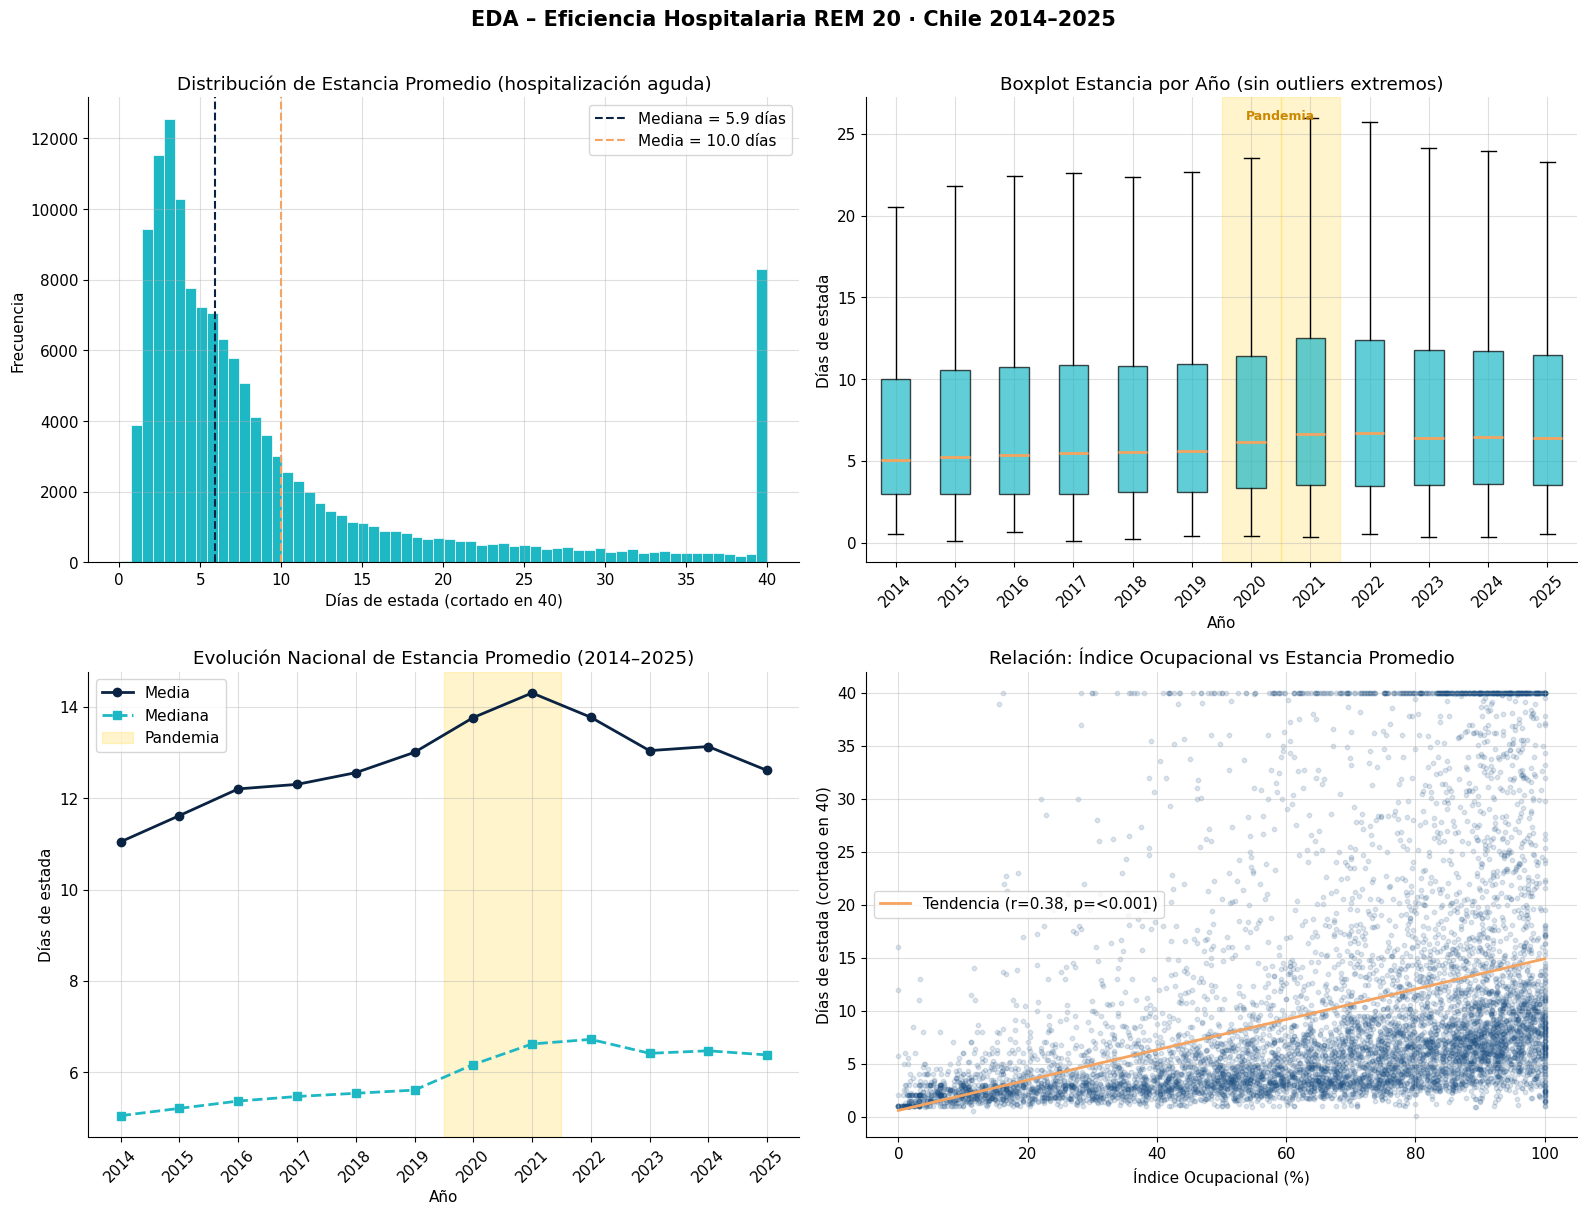

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("EDA – Eficiencia Hospitalaria REM 20 · Chile 2014–2025",
             fontsize=15, fontweight="bold", y=1.01)

#Histograma estancia 
ax1 = axes[0, 0]
datos_hist = df_aguda["PROMEDIO_DIAS_ESTADA"].clip(upper=40)
ax1.hist(datos_hist, bins=60, color="#1EB8C5", edgecolor="white", linewidth=0.5)
ax1.axvline(datos_hist.median(), color="#0A2342", linestyle="--", linewidth=1.5,
            label=f"Mediana = {datos_hist.median():.1f} días")
ax1.axvline(datos_hist.mean(),   color="#F4A460", linestyle="--", linewidth=1.5,
            label=f"Media = {datos_hist.mean():.1f} días")
ax1.set_title("Distribución de Estancia Promedio (hospitalización aguda)")
ax1.set_xlabel("Días de estada (cortado en 40)")
ax1.set_ylabel("Frecuencia")
ax1.legend()

# Boxplot por período
ax2 = axes[0, 1]
# Agrupar datos por año
grupos_anio = [df_aguda[df_aguda["PERIODO"]==y]["PROMEDIO_DIAS_ESTADA"].clip(upper=50).values
               for y in sorted(df_aguda["PERIODO"].unique())]
labels_anio = sorted(df_aguda["PERIODO"].unique())
bp = ax2.boxplot(grupos_anio, labels=labels_anio,
                 patch_artist=True, showfliers=False,
                 medianprops=dict(color="#F4A460", linewidth=2))
for patch in bp["boxes"]:
    patch.set_facecolor("#1EB8C5")
    patch.set_alpha(0.7)
ax2.set_title("Boxplot Estancia por Año (sin outliers extremos)")
ax2.set_xlabel("Año")
ax2.set_ylabel("Días de estada")
ax2.tick_params(axis="x", rotation=45)
# Marcar pandemia
for x_pos in [7, 8]:
    ax2.axvspan(x_pos - 0.5, x_pos + 0.5, color="#FFCC00", alpha=0.2)
ax2.text(7.5, ax2.get_ylim()[1]*0.95, "Pandemia", ha="center",
         fontsize=9, color="#CC8800", fontweight="bold")

#Evolución temporal
ax3 = axes[1, 0]
evolucion = df_aguda.groupby("PERIODO")["PROMEDIO_DIAS_ESTADA"].agg(["mean","median"]).reset_index()
ax3.plot(evolucion["PERIODO"], evolucion["mean"],
         marker="o", linewidth=2, color="#0A2342", label="Media")
ax3.plot(evolucion["PERIODO"], evolucion["median"],
         marker="s", linewidth=2, color="#1EB8C5", linestyle="--", label="Mediana")
ax3.axvspan(2019.5, 2021.5, color="#FFCC00", alpha=0.2, label="Pandemia")
ax3.set_title("Evolución Nacional de Estancia Promedio (2014–2025)")
ax3.set_xlabel("Año")
ax3.set_ylabel("Días de estada")
ax3.legend()
ax3.xaxis.set_major_locator(mticker.MultipleLocator(1))
ax3.tick_params(axis="x", rotation=45)

#Dispersión Índice Ocupacional vs Estancia
ax4 = axes[1, 1]
sample = df_aguda[["INDICE_OCUPACIONAL","PROMEDIO_DIAS_ESTADA"]].dropna().sample(
            n=min(8000, len(df_aguda)), random_state=42)
ax4.scatter(sample["INDICE_OCUPACIONAL"], sample["PROMEDIO_DIAS_ESTADA"].clip(upper=40),
            alpha=0.15, s=10, color="#1C4F82")
# Línea de tendencia
m, b, r, p_val, _ = stats.linregress(sample["INDICE_OCUPACIONAL"],
                                      sample["PROMEDIO_DIAS_ESTADA"].clip(upper=40))
x_line = np.linspace(0, 100, 100)
ax4.plot(x_line, m*x_line + b, color="#F4A460", linewidth=2,
         label=f"Tendencia (r={r:.2f}, p={'<0.001' if p_val<0.001 else f'{p_val:.3f}'})")
ax4.set_title("Relación: Índice Ocupacional vs Estancia Promedio")
ax4.set_xlabel("Índice Ocupacional (%)")
ax4.set_ylabel("Días de estada (cortado en 40)")
ax4.legend()

plt.tight_layout()
plt.savefig("eda_eficiencia_hospitalaria.png", dpi=150, bbox_inches="tight")
plt.show()



### 3.5 Z-Score de eficiencia por hospital

Se estandariza la estancia de cada hospital **dentro de su área funcional**, controlando
así la diferencia de complejidad clínica. Un Z > 1 indica estancias sistemáticamente más
largas que la media de hospitales similares.


In [16]:
df_aguda["z_estancia"] = df_aguda.groupby("AREA_FUNCIONAL")["PROMEDIO_DIAS_ESTADA"].transform(
    lambda x: (x - x.mean()) / x.std() if x.std() > 0 else 0
)

z_hosp = (df_aguda.groupby("ESTABLECIMIENTO")["z_estancia"]
            .agg(["mean", "count"])
            .query("count >= 24")          # mínimo 24 meses de datos
            .rename(columns={"mean": "Z_medio", "count": "N_registros"})
            .sort_values("Z_medio", ascending=False))

print("Hospitales con mayor Z (menos eficientes en su área)")
print(z_hosp.head(10).round(3).to_string())
print()
print("Hospitales con menor Z (más eficientes en su área)")
print(z_hosp.tail(10).round(3).to_string())
print()
print(f"Hospitales Z > 1 (menos eficientes): {(z_hosp['Z_medio'] > 1).sum()}")
print(f"Hospitales Z < -1 (más eficientes) : {(z_hosp['Z_medio'] < -1).sum()}")


Hospitales con mayor Z (menos eficientes en su área)
                                                                       Z_medio  N_registros
ESTABLECIMIENTO                                                                            
Centro de Enfermedades Respiratorias Infantiles Josefina Martínez        9.169           34
Hospital Psiquiátrico El Peral (Santiago, Puente Alto)                   4.599           96
Centro de Enfermedades Respiratorias Infantiles Josefina Martínez (D)    3.707           81
Hospital San José de Maipo                                               2.449          405
Hospital de Alto Hospicio                                                1.681          133
Hospital Juana Ross de Edwards (Peñablanca, Villa Alemana)               1.503          162
Hospital de Curacaví                                                     1.456          144
Hospital Centro Geriátrico Paz de la Tarde (Limache)                     1.204          144
Hospital de Lolol          

## 4. Estimacion Estadistica

### 4.1 Estimadores puntuales - Parametros de interes

Para caracterizar la poblacion de servicios hospitalarios chilenos se calculan estimadores puntuales de **media** y **proporciones**, junto con sus intervalos de confianza al 95% (distribucion t de Student para medias, aproximacion normal para proporciones).


In [17]:
from scipy.stats import t as t_dist

def ic_media(serie, confianza=0.95):
    """Intervalo de confianza para la media (t de Student)."""
    n    = len(serie.dropna())
    mean = serie.mean()
    sem  = stats.sem(serie.dropna())
    margen = t_dist.ppf((1 + confianza) / 2, df=n-1) * sem
    return mean, mean - margen, mean + margen

#Estancia promedio nacional 
media, li, ls = ic_media(df_aguda["PROMEDIO_DIAS_ESTADA"])
mediana = df_aguda["PROMEDIO_DIAS_ESTADA"].median()
print(f"PROMEDIO_DIAS_ESTADA (hospitalización aguda):")
print(f"  Media     = {media:.3f} días")
print(f"  Mediana   = {mediana:.3f} días")
print(f"  IC 95%    = ({li:.3f} ; {ls:.3f})")
print()

#Índice Ocupacional promedio nacional 
media_o, li_o, ls_o = ic_media(df_aguda["INDICE_OCUPACIONAL"])
mediana_o = df_aguda["INDICE_OCUPACIONAL"].median()
print(f"INDICE_OCUPACIONAL (hospitalización aguda):")
print(f"  Media     = {media_o:.3f} %")
print(f"  Mediana   = {mediana_o:.3f} %")
print(f"  IC 95%    = ({li_o:.3f} ; {ls_o:.3f})")
print()

#Proporción de servicios con ocupación ≥ 85% 
prop_sat = (df_aguda["INDICE_OCUPACIONAL"] >= 85).mean()
n_prop   = len(df_aguda)
se_prop  = np.sqrt(prop_sat * (1 - prop_sat) / n_prop)
z_95     = 1.96
print(f"Proporción registros con ocupación ≥ 85%:")
print(f"  p̂ = {prop_sat:.4f}  ({prop_sat*100:.2f}%)")
print(f"  IC 95% = ({prop_sat - z_95*se_prop:.4f} ; {prop_sat + z_95*se_prop:.4f})")


PROMEDIO_DIAS_ESTADA (hospitalización aguda):
  Media     = 12.772 días
  Mediana   = 5.930 días
  IC 95%    = (12.583 ; 12.961)

INDICE_OCUPACIONAL (hospitalización aguda):
  Media     = 64.883 %
  Mediana   = 71.770 %
  IC 95%    = (64.736 ; 65.029)

Proporción registros con ocupación ≥ 85%:
  p̂ = 0.3052  (30.52%)
  IC 95% = (0.3027 ; 0.3076)


### 4.2 Comparación entre grupos

Las cinco preguntas de investigación se abordan como sigue:

| # | Pregunta | Variables | Método |
|---|----------|-----------|--------|
| 01 | ¿Existen hospitales con estancias sistemáticamente más largas para diagnósticos similares? | `PROMEDIO_DIAS_ESTADA` · `ESTABLECIMIENTO` | Z-score intra-área + Mann-Whitney |
| 02 | ¿La duración de hospitalización refleja diferencias en eficiencia hospitalaria? | `PROMEDIO_DIAS_ESTADA` · `INDICE_ROTACION` | Correlación de Spearman |
| 03 | ¿La complejidad clínica del área explica las diferencias entre hospitales? | `PROMEDIO_DIAS_ESTADA` · `AREA_FUNCIONAL` | Kruskal-Wallis + Eta² |
| 04 | ¿Hubo cambios significativos en la estancia durante la pandemia (2020–2021)? | `PROMEDIO_DIAS_ESTADA` · `PERIODO` | Mann-Whitney pre vs pandemia |
| 05 | ¿Qué servicios presentan mayores niveles de saturación? | `INDICE_OCUPACIONAL` · `AREA_FUNCIONAL` | Proporción con IC 95% por área |


#### Pregunta 01: ¿Existen hospitales con estancias sistemáticamente más largas para diagnósticos similares?

El **Z-score intra-área** estandariza la estancia de cada hospital *dentro de su área funcional*,
controlando así la complejidad clínica. Un Z > 1 indica que ese hospital tiene estancias
sistemáticamente más largas que hospitales comparables.

Luego se compara directamente la estancia entre los hospitales del decil superior (Z ≥ p90)
vs el decil inferior (Z ≤ p10) mediante **Mann-Whitney U** (unilateral).


Comparación de estancia — hospitales extremos
                                Grupo  N hospitales  N registros  Media (días)  Mediana (días)  Desv. Est.
Hospitales menos eficientes (Z ≥ p90)            30         7584        30.675           9.525     116.863
  Hospitales más eficientes (Z ≤ p10)            30        17135         5.885           3.940       7.550

Mann-Whitney U (unilateral — menos eficientes > más eficientes):
  U = 99503530,  p = <0.001

CV promedio intra-área: 102.5%

Interpretación:
  Sí existen hospitales sistemáticamente menos eficientes (p < 0.05).
  La mediana de estancia en el grupo menos eficiente es 5.6 días mayor
  que en el grupo más eficiente, controlando por área funcional.

Top 10 hospitales con mayor Z-score (menos eficientes en su área):
                                                                       Z_medio  N_registros
ESTABLECIMIENTO                                                                            
Centro de Enfermedades Respirato

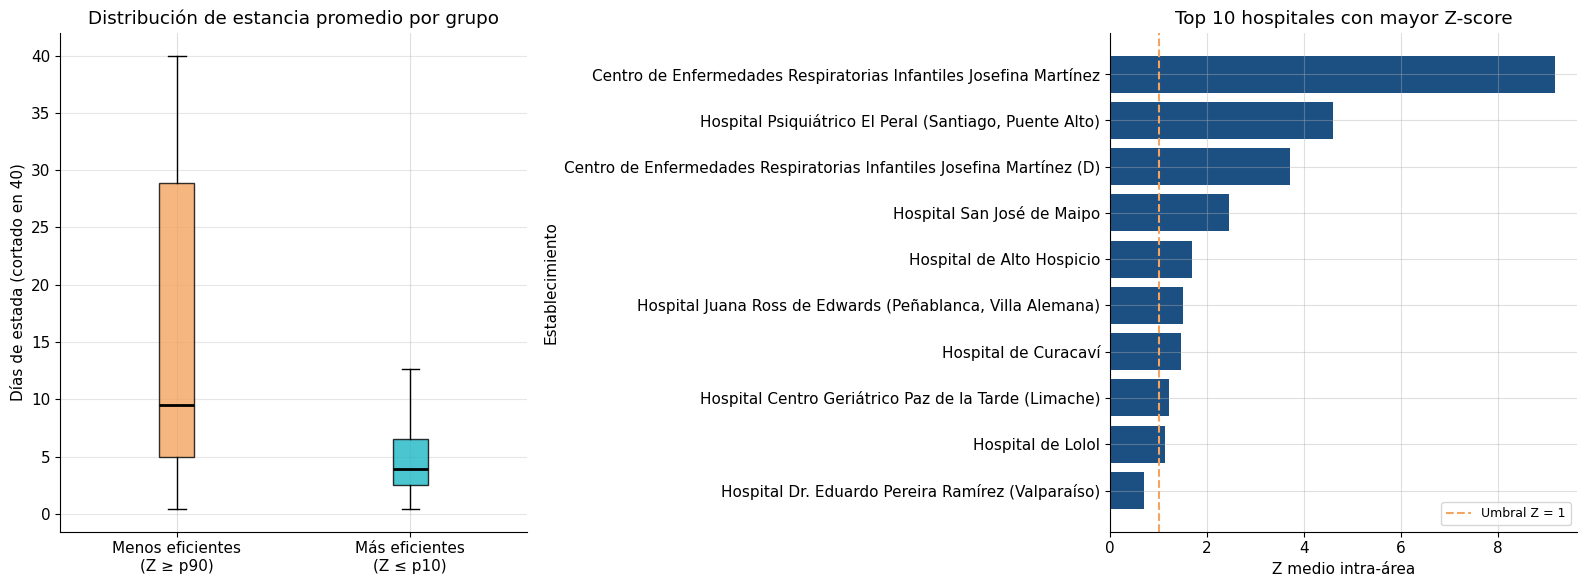

In [20]:


# Clasificar hospitales por eficiencia relativa 
q90 = z_hosp["Z_medio"].quantile(0.90)
q10 = z_hosp["Z_medio"].quantile(0.10)

hosp_menos_eficientes = z_hosp[z_hosp["Z_medio"] >= q90].index.tolist()
hosp_mas_eficientes   = z_hosp[z_hosp["Z_medio"] <= q10].index.tolist()

estancia_menos = df_aguda[df_aguda["ESTABLECIMIENTO"].isin(hosp_menos_eficientes)]["PROMEDIO_DIAS_ESTADA"]
estancia_mas   = df_aguda[df_aguda["ESTABLECIMIENTO"].isin(hosp_mas_eficientes)  ]["PROMEDIO_DIAS_ESTADA"]


tabla_p01 = pd.DataFrame({
    "Grupo"         : ["Hospitales menos eficientes (Z ≥ p90)", "Hospitales más eficientes (Z ≤ p10)"],
    "N hospitales"  : [len(hosp_menos_eficientes), len(hosp_mas_eficientes)],
    "N registros"   : [len(estancia_menos), len(estancia_mas)],
    "Media (días)"  : [estancia_menos.mean(), estancia_mas.mean()],
    "Mediana (días)": [estancia_menos.median(), estancia_mas.median()],
    "Desv. Est."    : [estancia_menos.std(), estancia_mas.std()],
}).round(3)

print("Comparación de estancia — hospitales extremos")
print(tabla_p01.to_string(index=False))
print()

# Test Mann-Whitney unilateral: ¿menos eficientes > más eficientes?
U_p01, p_p01 = stats.mannwhitneyu(estancia_menos, estancia_mas, alternative="greater")
print("Mann-Whitney U (unilateral — menos eficientes > más eficientes):")
print(f"  U = {U_p01:.0f},  p = {'<0.001' if p_p01 < 0.001 else f'{p_p01:.4f}'}")
print()


print(f"CV promedio intra-área: {df_variab['CV (%)'].mean():.1f}%")
print()
print("Interpretación:")
if p_p01 < 0.05:
    dif = estancia_menos.median() - estancia_mas.median()
    print("  Sí existen hospitales sistemáticamente menos eficientes (p < 0.05).")
    print(f"  La mediana de estancia en el grupo menos eficiente es {dif:.1f} días mayor")
    print("  que en el grupo más eficiente, controlando por área funcional.")
else:
    print("  No se detecta diferencia significativa (p ≥ 0.05).")

print()
print("Top 10 hospitales con mayor Z-score (menos eficientes en su área):")
print(z_hosp.head(10)[["Z_medio", "N_registros"]].round(3).to_string())


fig, axes = plt.subplots(1, 2, figsize=(16, 6))


# Boxplot comparativo de estancia
ax1 = axes[0]
grupos = [estancia_menos.clip(upper=40).values, estancia_mas.clip(upper=40).values]
labels = ["Menos eficientes\n(Z ≥ p90)", "Más eficientes\n(Z ≤ p10)"]
bp = ax1.boxplot(
    grupos, labels=labels, patch_artist=True, showfliers=False,
    medianprops=dict(color="black", linewidth=2)
)
for patch, color in zip(bp["boxes"], ["#F4A460", "#1EB8C5"]):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)

ax1.set_title("Distribución de estancia promedio por grupo")
ax1.set_ylabel("Días de estada (cortado en 40)")
ax1.grid(axis="y", alpha=0.3)

sig = "***" if p_p01 < 0.001 else ("**" if p_p01 < 0.01 else ("*" if p_p01 < 0.05 else "n.s."))


# Top 10 hospitales con mayor Z
ax2 = axes[1]
top10 = z_hosp.head(10).sort_values("Z_medio", ascending=True)
ax2.barh(top10.index, top10["Z_medio"], color="#1C4F82")
ax2.axvline(1, color="#F4A460", linestyle="--", linewidth=1.5, label="Umbral Z = 1")
ax2.set_title("Top 10 hospitales con mayor Z-score")
ax2.set_xlabel("Z medio intra-área")
ax2.set_ylabel("Establecimiento")
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()



#### Pregunta 02: ¿La duración de hospitalización refleja diferencias en eficiencia hospitalaria?

Se analiza la relación entre `PROMEDIO_DIAS_ESTADA` e `INDICE_ROTACION` agregados por hospital.
Un hospital eficiente debería tener estadías cortas **y** alta rotación de camas.
Se usa **correlación de Spearman** (no paramétrica) dado que ambas variables tienen distribuciones asimétricas.


Hospitales con datos suficientes (≥ 24 meses): 297

Estadísticos de eficiencia por hospital (extremos)
 Mayor estancia 
                                                      ESTABLECIMIENTO  estancia_media  rotacion_media  ocupacion_media
               Hospital Psiquiátrico El Peral (Santiago, Puente Alto)          347.13            0.23            67.84
Centro de Enfermedades Respiratorias Infantiles Josefina Martínez (D)          264.06            4.97            59.15
    Centro de Enfermedades Respiratorias Infantiles Josefina Martínez          236.75            8.57            69.68
                                           Hospital San José de Maipo           51.81            0.75            69.12
                                        Hospital Pu Mulen Quilacahuín           38.92            0.80            72.55

Menor estancia 
                                          ESTABLECIMIENTO  estancia_media  rotacion_media  ocupacion_media
              Hospital Dr Eduardo González

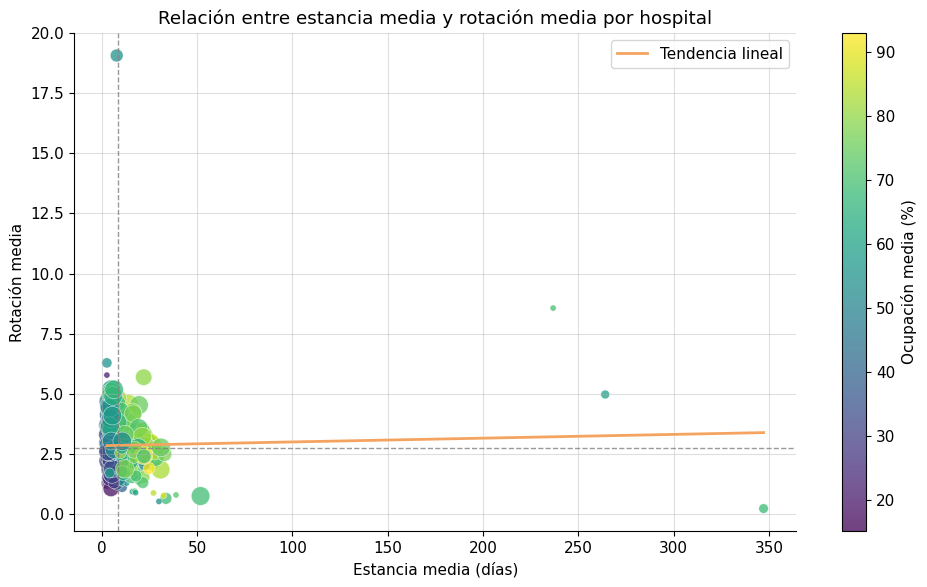

In [22]:
#Correlación estancia vs rotación
from scipy.stats import spearmanr

# Agregar por hospital 
hosp_efic = (df_aguda.groupby("ESTABLECIMIENTO")
    .agg(
        estancia_media  = ("PROMEDIO_DIAS_ESTADA", "mean"),
        rotacion_media  = ("INDICE_ROTACION",      "mean"),
        ocupacion_media = ("INDICE_OCUPACIONAL",   "mean"),
        n_registros     = ("PROMEDIO_DIAS_ESTADA", "count"),
    )
    .query("n_registros >= 24")
    .dropna()
    .reset_index()
)

rho, p_rho = spearmanr(hosp_efic["estancia_media"], hosp_efic["rotacion_media"])

print(f"Hospitales con datos suficientes (≥ 24 meses): {len(hosp_efic)}")
print()
print("Estadísticos de eficiencia por hospital (extremos)")
print(" Mayor estancia ")
print(hosp_efic.nlargest(5, "estancia_media")
      [["ESTABLECIMIENTO","estancia_media","rotacion_media","ocupacion_media"]]
      .round(2).to_string(index=False))
print()
print("Menor estancia ")
print(hosp_efic.nsmallest(5, "estancia_media")
      [["ESTABLECIMIENTO","estancia_media","rotacion_media","ocupacion_media"]]
      .round(2).to_string(index=False))
print()
print(f"Correlación de Spearman (estancia vs rotación):")
print(f"  rho = {rho:.3f},  p = {'<0.001' if p_rho < 0.001 else f'{p_rho:.4f}'}")
print()
print("Interpretación:")
if p_rho < 0.05 and rho < 0:
    print(f"  Correlación negativa significativa: hospitales con estancias más largas")
    print(f"  tienden a tener menor rotación de camas.")
    print(f"   PROMEDIO_DIAS_ESTADA es un proxy válido de ineficiencia hospitalaria.")
elif p_rho < 0.05 and rho > 0:
    print(f"  Correlación positiva: puede deberse a hospitales de mayor complejidad.")
else:
    print(f"  Sin correlación significativa (p ≥ 0.05).")


fig, ax = plt.subplots(figsize=(10, 6))

sizes = np.clip(hosp_efic["n_registros"] / 2, 20, 180)
sc = ax.scatter(
    hosp_efic["estancia_media"],
    hosp_efic["rotacion_media"],
    c=hosp_efic["ocupacion_media"],
    s=sizes,
    cmap="viridis",
    alpha=0.75,
    edgecolor="white",
    linewidth=0.4
)

# Línea de tendencia lineal 
m2, b2 = np.polyfit(hosp_efic["estancia_media"], hosp_efic["rotacion_media"], 1)
x_line = np.linspace(hosp_efic["estancia_media"].min(), hosp_efic["estancia_media"].max(), 200)
ax.plot(x_line, m2 * x_line + b2, color="#F4A460", linewidth=2, label="Tendencia lineal")

# Líneas de mediana (cuadrantes interpretables)
ax.axvline(hosp_efic["estancia_media"].median(), color="gray", linestyle="--", linewidth=1, alpha=0.8)
ax.axhline(hosp_efic["rotacion_media"].median(), color="gray", linestyle="--", linewidth=1, alpha=0.8)

ax.set_title("Relación entre estancia media y rotación media por hospital")
ax.set_xlabel("Estancia media (días)")
ax.set_ylabel("Rotación media")
ax.legend(loc="upper right")

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Ocupación media (%)")



plt.tight_layout()
plt.show()


#### Pregunta 03: ¿La complejidad clínica del área explica las diferencias entre hospitales?

Si la complejidad del área funcional explica completamente las diferencias de estancia,
los hospitales dentro de la **misma área** deberían ser homogéneos.
El **Kruskal-Wallis** prueba si las medianas de estancia difieren entre áreas.
El **Eta²** cuantifica qué proporción de la variabilidad total explica el área funcional.


Test Kruskal-Wallis entre 17 áreas funcionales:
  H = 86014.48,  p = <0.001

Eta² (tamaño del efecto) = 0.632

Mediana de estancia por área funcional (top 8 y bottom 5):
                                                    mediana      n
AREA_FUNCIONAL                                                    
Área Neonatología Cuidados Intensivos                 43.50   4168
Área Cuidados Intensivos Pediátricos                  27.00   3613
Área Cuidados Intensivos Adultos                      24.16   7687
Área Cuidados Intermedios Adultos                     17.62   9466
Área Neonatología Cuidados Intermedios                14.23   5480
Área Cuidados Intermedios Pediátricos                 11.74   5190
Área Médica Adulto Cuidados Medios                     9.09   5929
Área Médico-Quirúrgico Cuidados Medios                 7.40   9277
Área Médico-Quirúrgico Pediátrica Cuidados Medios      4.00   4459
Área Médico-Quirúrgico Pediátrica Cuidados Básicos     3.18   6172
Área Médica Pediátrica Cui

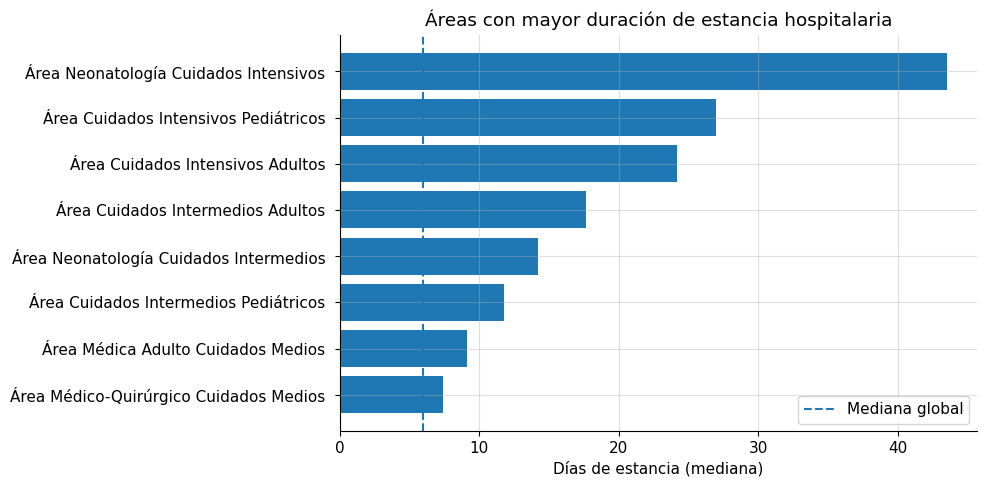

In [23]:
# Kruskal-Wallis ¿el área explica las diferencias?
from scipy.stats import kruskal
import seaborn as sns

# 1) Normalizar nombre de área 
df_kw = df_aguda.copy()
df_kw["AREA_FUNCIONAL"] = df_kw["AREA_FUNCIONAL"].str.strip()

# 2) Seleccionar áreas con tamaño mínimo
areas_comunes = (df_kw.groupby("AREA_FUNCIONAL")["PROMEDIO_DIAS_ESTADA"]
                 .count()
                 .loc[lambda x: x >= 100]
                 .index.tolist())

# 3) Kruskal-Wallis
grupos_kw = [df_kw.loc[df_kw["AREA_FUNCIONAL"] == a, "PROMEDIO_DIAS_ESTADA"].values
             for a in areas_comunes]

H, p_kw = kruskal(*grupos_kw)
print(f"Test Kruskal-Wallis entre {len(areas_comunes)} áreas funcionales:")
print(f"  H = {H:.2f},  p = {'<0.001' if p_kw < 0.001 else f'{p_kw:.4f}'}")
print()

# Eta² (tamaño del efecto)
n_total = sum(len(g) for g in grupos_kw)
eta2 = (H - len(grupos_kw) + 1) / (n_total - len(grupos_kw))
print(f"Eta² (tamaño del efecto) = {eta2:.3f}")

# 4) Resumen por área
mediana_area = (df_kw.groupby("AREA_FUNCIONAL")["PROMEDIO_DIAS_ESTADA"]
                .agg(mediana="median", n="count")
                .query("n >= 100")
                .sort_values("mediana", ascending=False))
print()
print("Mediana de estancia por área funcional (top 8 y bottom 5):")
print(pd.concat([mediana_area.head(8), mediana_area.tail(5)]).round(2).to_string())

# Calcular mediana por área
mediana_area = (df_aguda.groupby("AREA_FUNCIONAL")["PROMEDIO_DIAS_ESTADA"]
                .median()
                .sort_values(ascending=False))

# Tomar TOP 8 áreas 
top_areas = mediana_area.head(8)

plt.figure(figsize=(10,5))

plt.barh(top_areas.index[::-1], top_areas.values[::-1])

plt.title("Áreas con mayor duración de estancia hospitalaria")
plt.xlabel("Días de estancia (mediana)")
plt.ylabel("")


plt.axvline(df_aguda["PROMEDIO_DIAS_ESTADA"].median(),
            linestyle="--",
            label="Mediana global")

plt.legend()

plt.tight_layout()
plt.show()


#### Pregunta 04: ¿Hubo cambios significativos en la estancia durante la pandemia (2020–2021)?

Se comparan tres períodos usando **Mann-Whitney U** (test no paramétrico, apropiado porque
la distribución de estancia es fuertemente asimétrica, como se vio en el histograma del EDA):

- **Pre-pandemia**: 2017–2019 (3 años de referencia estables)
- **Pandemia**: 2020–2021
- **Post-pandemia**: 2022–2024


Tabla P04: Estadísticos de estancia por período
                Período     N  Media  Mediana  Desv. Est.  P25   P75
 Pre-pandemia (2017–19) 34593 12.622     5.53      29.701 3.08 10.85
     Pandemia (2020–21) 22339 14.031     6.38      58.372 3.43 11.92
Post-pandemia (2022–24) 33746 13.314     6.52      32.994 3.51 12.00

Test Mann-Whitney U (dos colas):
  Pre-pandemia vs Pandemia   : U = 359844348,  p = <0.001
  Pandemia vs Post-pandemia  : U = 372887118, p = 0.0314
  Pre-pandemia vs Post       : U = 536769778,  p = <0.001

Interpretación:
  La mediana de estancia aumentó 0.85 días durante la pandemia.
  Diferencia estadísticamente significativa: Sí (α = 0.05)


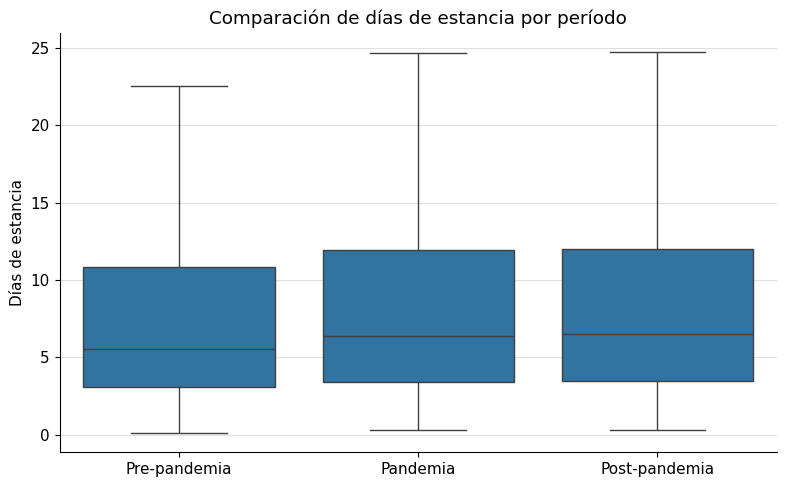

In [24]:
# Pandemia vs pre-pandemia 
pre  = df_aguda[df_aguda["PERIODO"].isin([2017, 2018, 2019])]["PROMEDIO_DIAS_ESTADA"]
pan  = df_aguda[df_aguda["PERIODO"].isin([2020, 2021])       ]["PROMEDIO_DIAS_ESTADA"]
post = df_aguda[df_aguda["PERIODO"].isin([2022, 2023, 2024]) ]["PROMEDIO_DIAS_ESTADA"]

# Estadísticos descriptivos por período
resumen_pandemia = pd.DataFrame({
    "Período"    : ["Pre-pandemia (2017–19)", "Pandemia (2020–21)", "Post-pandemia (2022–24)"],
    "N"          : [len(pre), len(pan), len(post)],
    "Media"      : [pre.mean(), pan.mean(), post.mean()],
    "Mediana"    : [pre.median(), pan.median(), post.median()],
    "Desv. Est." : [pre.std(), pan.std(), post.std()],
    "P25"        : [pre.quantile(0.25), pan.quantile(0.25), post.quantile(0.25)],
    "P75"        : [pre.quantile(0.75), pan.quantile(0.75), post.quantile(0.75)],
}).round(3)

print("Tabla P04: Estadísticos de estancia por período")
print(resumen_pandemia.to_string(index=False))
print()

# Tests Mann-Whitney 
U_pre_pan,  p_pre_pan  = stats.mannwhitneyu(pre, pan,  alternative="two-sided")
U_pan_post, p_pan_post = stats.mannwhitneyu(pan, post, alternative="two-sided")
U_pre_post, p_pre_post = stats.mannwhitneyu(pre, post, alternative="two-sided")

print("Test Mann-Whitney U (dos colas):")
print(f"  Pre-pandemia vs Pandemia   : U = {U_pre_pan:.0f},  p = {'<0.001' if p_pre_pan  < 0.001 else f'{p_pre_pan:.4f}'}")
print(f"  Pandemia vs Post-pandemia  : U = {U_pan_post:.0f}, p = {'<0.001' if p_pan_post < 0.001 else f'{p_pan_post:.4f}'}")
print(f"  Pre-pandemia vs Post       : U = {U_pre_post:.0f},  p = {'<0.001' if p_pre_post < 0.001 else f'{p_pre_post:.4f}'}")
print()
print("Interpretación:")
dif = pan.median() - pre.median()
sig = "Sí" if p_pre_pan < 0.05 else "No"
print(f"  La mediana de estancia {'aumentó' if dif > 0 else 'disminuyó'} {abs(dif):.2f} días durante la pandemia.")
print(f"  Diferencia estadísticamente significativa: {sig} (α = 0.05)")

df_pandemia = pd.DataFrame({
    "Estancia": pd.concat([pre, pan, post]),
    "Periodo": (["Pre-pandemia"] * len(pre) +
                ["Pandemia"] * len(pan) +
                ["Post-pandemia"] * len(post))
})

plt.figure(figsize=(8,5))

sns.boxplot(data=df_pandemia,
            x="Periodo",
            y="Estancia",
            showfliers=False)

plt.title("Comparación de días de estancia por período")
plt.xlabel("")
plt.ylabel("Días de estancia")

plt.tight_layout()
plt.show()

#### Pregunta 05: ¿Qué servicios presentan mayores niveles de saturación?

Se calcula la **proporción de registros con `INDICE_OCUPACIONAL ≥ 85%`** por área funcional.
85% es el umbral ampliamente utilizado en gestión hospitalaria para definir saturación operativa.
Se construyen **IC 95%** para cada proporción usando la aproximación normal.

Esta pregunta usa el dataset completo `df` (sin excluir psiquiatría/sociosanitaria),
ya que la saturación es relevante en todas las áreas.


Saturación por área funcional (umbral ≥ 85%)
                                                                   AREA_FUNCIONAL  N_registros  Media_ocupac  Mediana_ocupac  Prop_saturados
                                           Área Psiquiatría Adulto Larga estadía         292.0        89.955          95.095           0.774
                                     Área Psiquiatría Forense Adulto tratamiento         347.0        87.415          91.290           0.723
                                              Área Médica Adulto Cuidados Medios        5929.0        86.710          91.040           0.695
                        Área Psiquiatría Forense Adulto evaluación e inicio tto.         398.0        83.813          91.435           0.671
             Área de Hospitalización de Cuidados Intensivos en Psiquiatría Adulto        215.0        87.172          95.700           0.670
                                           Área Psiquiatría Adulto Corta estadía        4079.0        85.781 

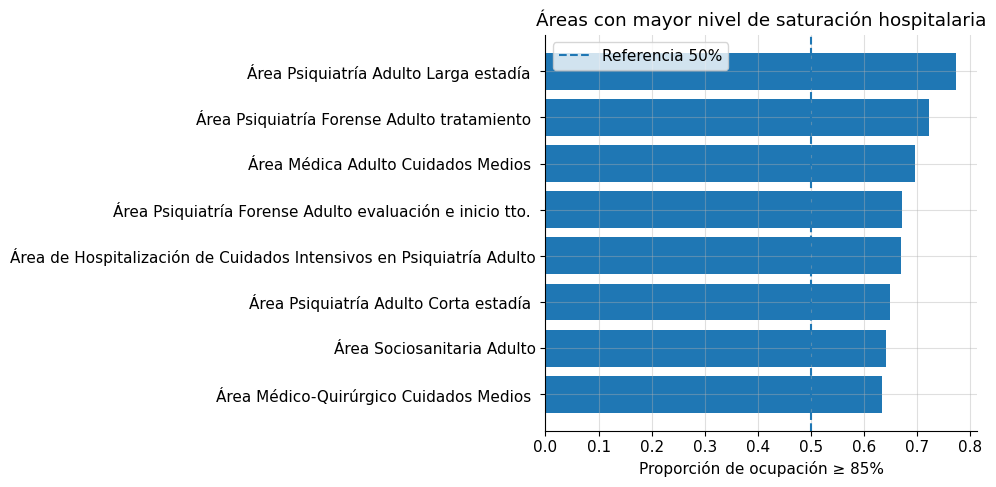

In [26]:
# Saturación por área funcional 
UMBRAL_SAT = 85

sat_por_area = (df.groupby("AREA_FUNCIONAL")
    .apply(lambda g: pd.Series({
        "N_registros"   : len(g),
        "Media_ocupac"  : g["INDICE_OCUPACIONAL"].mean(),
        "Mediana_ocupac": g["INDICE_OCUPACIONAL"].median(),
        "Prop_saturados": (g["INDICE_OCUPACIONAL"] >= UMBRAL_SAT).mean(),
    }))
    .round(3)
    .sort_values("Prop_saturados", ascending=False)
    .reset_index()
)

print(f"Saturación por área funcional (umbral ≥ {UMBRAL_SAT}%)")
print(sat_por_area.head(15).to_string(index=False))
print()

# IC 95% para proporción de saturación (top 5 áreas)
print(f"IC 95% para proporción de saturación — top 5 áreas:")
for _, row in sat_por_area.head(5).iterrows():
    p_hat = row["Prop_saturados"]
    n     = row["N_registros"]
    se    = np.sqrt(p_hat * (1 - p_hat) / n)
    li    = max(0, p_hat - 1.96 * se)
    ls    = min(1, p_hat + 1.96 * se)
    print(f"  {row['AREA_FUNCIONAL'][:55]:<57}"
          f"p̂ = {p_hat:.3f}  IC95% = ({li:.3f} ; {ls:.3f})")

top_sat = sat_por_area.head(8)

plt.figure(figsize=(10,5))

plt.barh(top_sat["AREA_FUNCIONAL"][::-1],
         top_sat["Prop_saturados"][::-1])

plt.title("Áreas con mayor nivel de saturación hospitalaria")
plt.xlabel("Proporción de ocupación ≥ 85%")
plt.ylabel("")

plt.axvline(0.5, linestyle="--", label="Referencia 50%")

plt.legend()
plt.tight_layout()
plt.show()

### 4.3 Tabla resumen de estimadores


In [27]:
# Tabla resumen global 
resumen_global = pd.DataFrame({
    "Variable"        : ["PROMEDIO_DIAS_ESTADA (aguda)", "INDICE_OCUPACIONAL (aguda)",
                         "INDICE_OCUPACIONAL (todo dataset)", "Prop. registros con occ. ≥ 85%"],
    "N"               : [len(df_aguda["PROMEDIO_DIAS_ESTADA"]),
                         len(df_aguda["INDICE_OCUPACIONAL"]),
                         len(df["INDICE_OCUPACIONAL"]),
                         len(df_aguda["INDICE_OCUPACIONAL"])],
    "Media"           : [df_aguda["PROMEDIO_DIAS_ESTADA"].mean(),
                         df_aguda["INDICE_OCUPACIONAL"].mean(),
                         df["INDICE_OCUPACIONAL"].mean(),
                         (df_aguda["INDICE_OCUPACIONAL"] >= 85).mean()],
    "Mediana"         : [df_aguda["PROMEDIO_DIAS_ESTADA"].median(),
                         df_aguda["INDICE_OCUPACIONAL"].median(),
                         df["INDICE_OCUPACIONAL"].median(),
                         np.nan],
    "Desv. Estándar"  : [df_aguda["PROMEDIO_DIAS_ESTADA"].std(),
                         df_aguda["INDICE_OCUPACIONAL"].std(),
                         df["INDICE_OCUPACIONAL"].std(),
                         np.nan],
    "IC 95% inferior" : [ic_media(df_aguda["PROMEDIO_DIAS_ESTADA"])[1],
                         ic_media(df_aguda["INDICE_OCUPACIONAL"])[1],
                         ic_media(df["INDICE_OCUPACIONAL"])[1],
                         (df_aguda["INDICE_OCUPACIONAL"]>=85).mean() - 1.96*np.sqrt(
                             (df_aguda["INDICE_OCUPACIONAL"]>=85).mean()*(1-(df_aguda["INDICE_OCUPACIONAL"]>=85).mean())/len(df_aguda))],
    "IC 95% superior" : [ic_media(df_aguda["PROMEDIO_DIAS_ESTADA"])[2],
                         ic_media(df_aguda["INDICE_OCUPACIONAL"])[2],
                         ic_media(df["INDICE_OCUPACIONAL"])[2],
                         (df_aguda["INDICE_OCUPACIONAL"]>=85).mean() + 1.96*np.sqrt(
                             (df_aguda["INDICE_OCUPACIONAL"]>=85).mean()*(1-(df_aguda["INDICE_OCUPACIONAL"]>=85).mean())/len(df_aguda))],
}).round(4)

print("Resumen de estimadores puntuales e intervalos de confianza 95%")
print(resumen_global.to_string(index=False))


Resumen de estimadores puntuales e intervalos de confianza 95%
                         Variable      N   Media  Mediana  Desv. Estándar  IC 95% inferior  IC 95% superior
     PROMEDIO_DIAS_ESTADA (aguda) 136196 12.7720     5.93         35.5834          12.5830          12.9609
       INDICE_OCUPACIONAL (aguda) 136196 64.8826    71.77         27.5701          64.7362          65.0291
INDICE_OCUPACIONAL (todo dataset) 146781 66.2622    73.47         27.4387          66.1218          66.4025
   Prop. registros con occ. ≥ 85% 136196  0.3052      NaN             NaN           0.3027           0.3076


## 5. Visualizaciones de Estimación Estadística


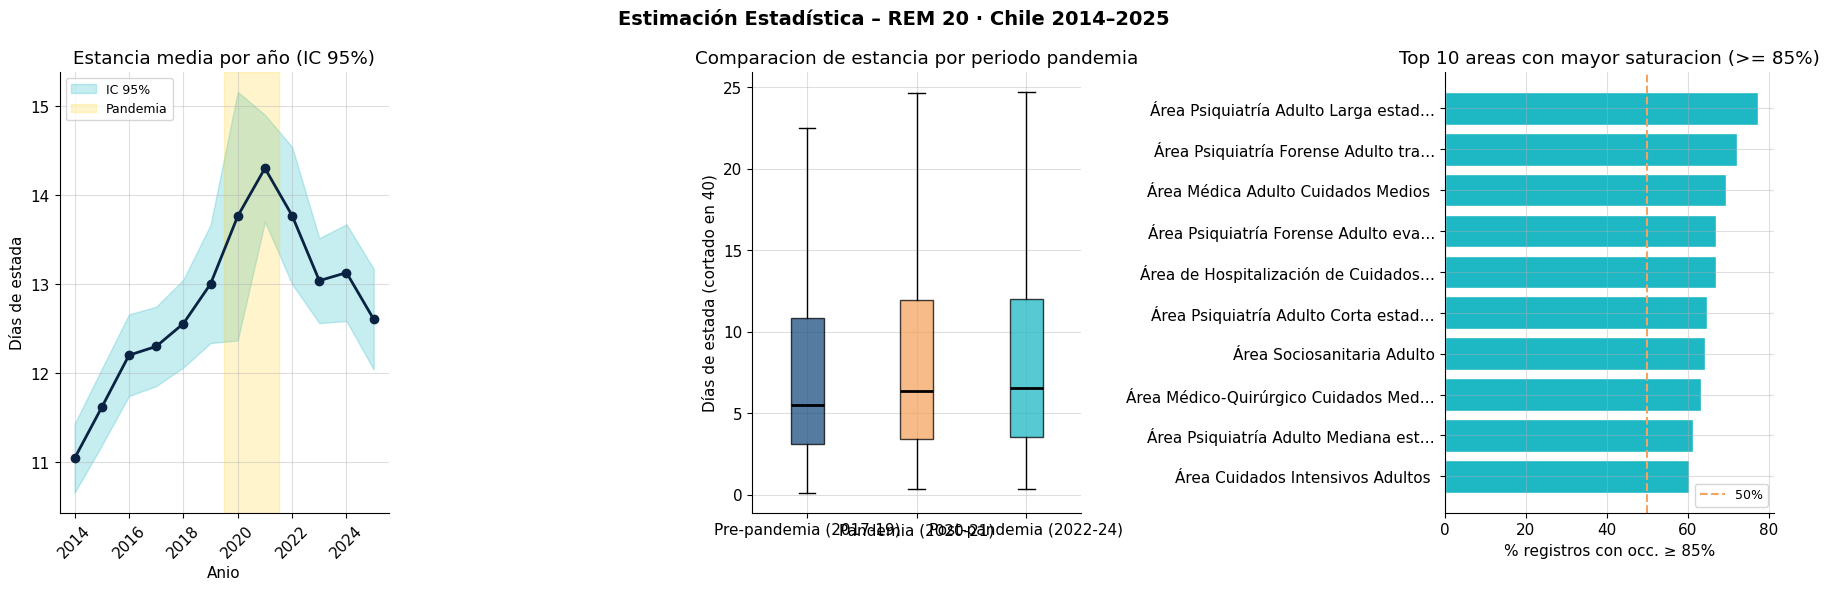

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Estimación Estadística – REM 20 · Chile 2014–2025",
             fontsize=14, fontweight="bold")

#Evolución estancia por período con IC
ax1 = axes[0]
evol_ic = (df_aguda.groupby("PERIODO")["PROMEDIO_DIAS_ESTADA"]
             .agg(media="mean",
                  li=lambda x: ic_media(x)[1],
                  ls=lambda x: ic_media(x)[2])
             .reset_index())
ax1.plot(evol_ic["PERIODO"], evol_ic["media"],
         marker="o", color="#0A2342", linewidth=2, zorder=3)
ax1.fill_between(evol_ic["PERIODO"], evol_ic["li"], evol_ic["ls"],
                 alpha=0.25, color="#1EB8C5", label="IC 95%")
ax1.axvspan(2019.5, 2021.5, color="#FFCC00", alpha=0.2, label="Pandemia")
ax1.set_title("Estancia media por año (IC 95%)")
ax1.set_xlabel("Anio")
ax1.set_ylabel("Días de estada")
ax1.legend(fontsize=9)
ax1.tick_params(axis="x", rotation=45)

#Comparación de grupos: pandemia 
ax2 = axes[1]
grupos_bp = [pre.clip(upper=40).values, pan.clip(upper=40).values, post.clip(upper=40).values]
labels_bp = ["Pre-pandemia (2017-19)", "Pandemia (2020-21)", "Post-pandemia (2022-24)"]
colors_bp = ["#1C4F82", "#F4A460", "#1EB8C5"]
bp2 = ax2.boxplot(grupos_bp, labels=labels_bp, patch_artist=True, showfliers=False,
                  medianprops=dict(color="black", linewidth=2))
for patch, color in zip(bp2["boxes"], colors_bp):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
ax2.set_title("Comparacion de estancia por periodo pandemia")
ax2.set_ylabel("Días de estada (cortado en 40)")
sig = "***" if p_pre_pan < 0.001 else ("**" if p_pre_pan < 0.01 else ("*" if p_pre_pan < 0.05 else "n.s."))


# Saturación top-10 áreas 
ax3 = axes[2]
top10_sat = sat_por_area.head(10)
# Acortar nombres largos
nombres_cortos = [n[:35] + "…" if len(n) > 35 else n for n in top10_sat["AREA_FUNCIONAL"]]
bars = ax3.barh(nombres_cortos, top10_sat["Prop_saturados"]*100,
                color="#1EB8C5", edgecolor="white")
ax3.axvline(50, color="#F4A460", linestyle="--", linewidth=1.5, label="50%")
ax3.set_title("Top 10 areas con mayor saturacion (>= 85%)")
ax3.set_xlabel("% registros con occ. ≥ 85%")
ax3.invert_yaxis()
ax3.legend(fontsize=9)

plt.tight_layout()
plt.show()



In [30]:
print("HALLAZGOS PRELIMINARES — 5 PREGUNTAS DE INVESTIGACIÓN")

print("¿Existen hospitales sistemáticamente menos eficientes?")
print(f"  Hospitales con estancia Z > 1 (menos eficientes): {(z_hosp['Z_medio']>1).sum()}")
print(f"  Hospitales con estancia Z < -1 (más eficientes) : {(z_hosp['Z_medio']<-1).sum()}")
print(f"  CV promedio intra-área: {df_variab['CV (%)'].mean():.1f}%  → Alta variabilidad entre hospitales.")


print("¿La estancia refleja diferencias en eficiencia?")
sig_rho = "Sí" if p_rho < 0.05 else "No"
print(f"  Spearman rho = {rho:.3f}  (p {'<0.001' if p_rho<0.001 else f'= {p_rho:.4f}'})")
print(f"  Correlación significativa: {sig_rho} → estancias largas se asocian a menor rotación.")


print("¿La complejidad clínica explica las diferencias?")
print(f"  Kruskal-Wallis H = {H:.2f}  (p {'<0.001' if p_kw<0.001 else f'= {p_kw:.4f}'})")
print(f"  Eta² ≈ {eta2:.3f} → el área funcional explica parte, pero no toda, la variabilidad.")
print(f"  Conclusión: la complejidad es relevante pero NO suficiente para explicar las diferencias.")


print("¿Cambió la estancia durante la pandemia?")
dif_median = pan.median() - pre.median()
sig_str = "Sí" if p_pre_pan < 0.05 else "No"
print(f"  Mediana pre-pandemia: {pre.median():.2f}  |  Pandemia: {pan.median():.2f}  |  Diferencia: {dif_median:+.2f} días")
print(f"  Mann-Whitney p {'<0.001' if p_pre_pan<0.001 else f'= {p_pre_pan:.4f}'}  → Diferencia significativa: {sig_str}")


print("¿Qué servicios presentan mayor saturación?")
top1 = sat_por_area.iloc[0]
print(f"  Área más saturada: {top1['AREA_FUNCIONAL']}")
print(f"  {top1['Prop_saturados']*100:.1f}% de sus registros tienen ocupación ≥ 85%")




HALLAZGOS PRELIMINARES — 5 PREGUNTAS DE INVESTIGACIÓN
¿Existen hospitales sistemáticamente menos eficientes?
  Hospitales con estancia Z > 1 (menos eficientes): 9
  Hospitales con estancia Z < -1 (más eficientes) : 0
  CV promedio intra-área: 102.5%  → Alta variabilidad entre hospitales.
¿La estancia refleja diferencias en eficiencia?
  Spearman rho = -0.114  (p = 0.0492)
  Correlación significativa: Sí → estancias largas se asocian a menor rotación.
¿La complejidad clínica explica las diferencias?
  Kruskal-Wallis H = 86014.48  (p <0.001)
  Eta² ≈ 0.632 → el área funcional explica parte, pero no toda, la variabilidad.
  Conclusión: la complejidad es relevante pero NO suficiente para explicar las diferencias.
¿Cambió la estancia durante la pandemia?
  Mediana pre-pandemia: 5.53  |  Pandemia: 6.38  |  Diferencia: +0.85 días
  Mann-Whitney p <0.001  → Diferencia significativa: Sí
¿Qué servicios presentan mayor saturación?
  Área más saturada: Área Psiquiatría Adulto Larga estadía 
  77.4